In [ ]:
# ==========================================
# Install AASIST
# ==========================================

import os

if not os.path.exists("/content/aasist"):
    !git clone https://github.com/clovaai/aasist.git

!pip install -q torchcontrib soundfile scikit-learn

Cloning into 'aasist'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 38 (delta 12), reused 6 (delta 6), pack-reused 10 (from 1)
Receiving objects: 100% (38/38), 1.43 MiB | 12.59 MiB/s, done.
Resolving deltas: 100% (12/12), done.
  Preparing metadata (setup.py) ... done


In [ ]:
# ==========================================
# Imports
# ==========================================

import os
import sys
import json
import random
import numpy as np
import pandas as pd
import torch
import torchaudio
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from torch.utils.data import (
    Dataset,
    DataLoader,
    Subset
)
from torch.optim import AdamW
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    auc
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("Copying dataset from Google Drive to local storage...")

if not os.path.exists("/content/dataset_split"):
    !cp -r "/content/drive/MyDrive/dataset_split" "/content/"
    print("Dataset copied successfully!")
else:
    print("Dataset already exists in /content/dataset_split")

# ==========================================
# CONFIG
# ==========================================

CONFIG = {

    # שם הניסוי
    "experiment_name": "aasist_exp_001",

    # Reproducibility
    "seed": 42,

    # Audio
    "target_sample_rate": 16000,

    # AASIST expects fixed-length input
    "nb_samp": 64600,

    # Training
    "batch_size": 4,
    "epochs": 30,
    "learning_rate": 1e-4,
    "weight_decay": 1e-4,

    # Split
    "val_ratio": 0.15,

    # Early Stopping
    "patience": 5,

    # Paths
    "train_dir": "/content/dataset_split/train",
    "test_dir": "/content/dataset_split/test",

    # Results
    "results_dir": "/content/results"
}

# ==========================================
# Seeds
# ==========================================

SEED = CONFIG["seed"]

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ==========================================
# Derived values
# ==========================================

TARGET_SAMPLE_RATE = CONFIG["target_sample_rate"]
NB_SAMP = CONFIG["nb_samp"]

BATCH_SIZE = CONFIG["batch_size"]
EPOCHS = CONFIG["epochs"]
LR = CONFIG["learning_rate"]

VAL_RATIO = CONFIG["val_ratio"]
PATIENCE = CONFIG["patience"]

TRAIN_DIR = CONFIG["train_dir"]
TEST_DIR = CONFIG["test_dir"]

# ==========================================
# Results folders
# ==========================================

EXPERIMENT_DIR = os.path.join(
    CONFIG["results_dir"],
    CONFIG["experiment_name"]
)

os.makedirs(EXPERIMENT_DIR, exist_ok=True)

BEST_MODEL_PATH = os.path.join(
    EXPERIMENT_DIR,
    "best_model.pt"
)

# ==========================================
# Device
# ==========================================

device = torch.device(
    'cuda' if torch.cuda.is_available() else 'cpu'
)

print(f"Using device: {device}")
print(f"Experiment: {CONFIG['experiment_name']}")
print(f"Results folder: {EXPERIMENT_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
Experiment: aasist_exp_001
Results folder: /content/results/aasist_exp_001


In [ ]:
sys.path.append("/content/aasist")
from models.AASIST import Model

In [ ]:
# ==========================================
# טעינת מודל AASIST
# ==========================================

sys.path.append("/content/aasist")

from models.AASIST import Model

# ==========================================
# AASIST Configuration
# ==========================================

aasist_config = {
    "architecture": "AASIST",

    "nb_samp": CONFIG["nb_samp"],

    "first_conv": 128,

    "filts": [
        70,
        [1, 32],
        [32, 32],
        [32, 64],
        [64, 64]
    ],

    "gat_dims": [64, 32],

    "pool_ratios": [
        0.5,
        0.7,
        0.5,
        0.5
    ],

    "temperatures": [
        2.0,
        2.0,
        100.0,
        100.0
    ]
}

# ==========================================
# Model
# ==========================================

model = Model(aasist_config).to(device)

# ==========================================
# Optimizer
# ==========================================

optimizer = AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=CONFIG["weight_decay"]
)

print("\nModel loaded successfully")
print("Model:", model.__class__.__name__)
print("Learning Rate:", LR)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"\nTotal Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")


Model loaded successfully
Model: Model
Learning Rate: 0.0001

Total Parameters: 297,866
Trainable Parameters: 297,866


In [ ]:
class DeepfakeAudioDatasetAASIST(Dataset):
    def __init__(self, root_dir, nb_samp=64600, target_sample_rate=16000, mode='train'):
        self.samples = []
        self.nb_samp = nb_samp
        self.target_sample_rate = target_sample_rate
        self.mode = mode
        self.valid_exts = ('.wav', '.mp3', '.flac', '.m4a')

        # real = 0
        real_dir = os.path.join(root_dir, 'real')
        if os.path.exists(real_dir):
            for file in os.listdir(real_dir):
                if file.lower().endswith(self.valid_exts):
                    self.samples.append({
                        "path": os.path.join(real_dir, file),
                        "label": 0,
                        "attack_type": "real"
                    })

        # fake = 1
        fake_dir = os.path.join(root_dir, 'fake')
        if os.path.exists(fake_dir):
            for attack_folder in os.listdir(fake_dir):
                attack_path = os.path.join(fake_dir, attack_folder)

                if os.path.isdir(attack_path):
                    for subdir, _, files in os.walk(attack_path):
                        for file in files:
                            if file.lower().endswith(self.valid_exts):
                                self.samples.append({
                                    "path": os.path.join(subdir, file),
                                    "label": 1,
                                    "attack_type": attack_folder
                                })

        self.filepaths = [s["path"] for s in self.samples]
        self.labels = [s["label"] for s in self.samples]
        self.attack_types = [s["attack_type"] for s in self.samples]

        print(f"[{mode}] Loaded {len(self.samples)} files from {root_dir}")

    def __len__(self):
        return len(self.samples)

    def _load_audio(self, filepath):
        waveform, sample_rate = torchaudio.load(filepath)

        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        if sample_rate != self.target_sample_rate:
            resampler = torchaudio.transforms.Resample(
                orig_freq=sample_rate,
                new_freq=self.target_sample_rate
            )
            waveform = resampler(waveform)

        return waveform.squeeze(0)

    def _crop_or_pad(self, waveform):
        length = waveform.shape[0]

        if length > self.nb_samp:
            if self.mode == 'train':
                start = random.randint(0, length - self.nb_samp)
            else:
                start = (length - self.nb_samp) // 2

            waveform = waveform[start:start + self.nb_samp]

        else:
            pad_length = self.nb_samp - length
            waveform = F.pad(waveform, (0, pad_length))

        return waveform

    def __getitem__(self, idx):
        sample = self.samples[idx]

        waveform = self._load_audio(sample["path"])
        waveform = self._crop_or_pad(waveform)

        return {
            "input_values": waveform,
            "labels": torch.tensor(sample["label"], dtype=torch.long),

            # חשוב לדוחות בהמשך
            "path": sample["path"],
            "attack_type": sample["attack_type"]
        }

In [ ]:
def stratified_split_by_attack(dataset, val_ratio=0.15, seed=42):
    random.seed(seed)

    group_to_indices = {}
    for idx, attack_type in enumerate(dataset.attack_types):
        group_to_indices.setdefault(attack_type, []).append(idx)

    train_indices = []
    val_indices = []

    print("Split summary by class/attack type:")
    print("-" * 60)

    for group_name, indices in group_to_indices.items():
        random.shuffle(indices)

        if len(indices) == 1:
            train_group = indices
            val_group = []
        else:
            n_val = max(1, int(len(indices) * val_ratio))
            if n_val >= len(indices):
                n_val = len(indices) - 1

            val_group = indices[:n_val]
            train_group = indices[n_val:]

        train_indices.extend(train_group)
        val_indices.extend(val_group)

        print(f"{group_name:35s} train={len(train_group):4d} | val={len(val_group):4d} | total={len(indices):4d}")

    random.shuffle(train_indices)
    random.shuffle(val_indices)

    return train_indices, val_indices

In [ ]:
# ==========================================
# יצירת datasets
# ==========================================

full_train_dataset_for_train = DeepfakeAudioDatasetAASIST(
    root_dir=TRAIN_DIR,
    nb_samp=NB_SAMP,
    target_sample_rate=TARGET_SAMPLE_RATE,
    mode='train'
)

full_train_dataset_for_val = DeepfakeAudioDatasetAASIST(
    root_dir=TRAIN_DIR,
    nb_samp=NB_SAMP,
    target_sample_rate=TARGET_SAMPLE_RATE,
    mode='val'
)

test_dataset = DeepfakeAudioDatasetAASIST(
    root_dir=TEST_DIR,
    nb_samp=NB_SAMP,
    target_sample_rate=TARGET_SAMPLE_RATE,
    mode='test'
)

# ==========================================
# Train / Validation Split
# ==========================================

train_indices, val_indices = stratified_split_by_attack(
    full_train_dataset_for_train,
    val_ratio=VAL_RATIO,
    seed=SEED
)

train_dataset = Subset(
    full_train_dataset_for_train,
    train_indices
)

val_dataset = Subset(
    full_train_dataset_for_val,
    val_indices
)

# ==========================================
# DataLoaders
# ==========================================

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("\nDataset sizes:")
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")
print(f"Test samples:  {len(test_dataset)}")

print("\nUnique attack types:")
print(sorted(set(full_train_dataset_for_train.attack_types)))

[train] Loaded 10625 files from /content/drive/MyDrive/dataset_split/train
[val] Loaded 10625 files from /content/drive/MyDrive/dataset_split/train
[test] Loaded 2661 files from /content/drive/MyDrive/dataset_split/test
Split summary by class/attack type:
------------------------------------------------------------
real                                train=4517 | val= 797 | total=5314
unknown                             train= 753 | val= 132 | total= 885
waveform_concatenation              train= 753 | val= 132 | total= 885
neural_vocoder_nonautoregressive    train= 753 | val= 132 | total= 885
neural_vocoder_autoregressive       train= 753 | val= 132 | total= 885
traditional_vocoder                 train= 753 | val= 132 | total= 885
elevenlabs_fake                     train= 754 | val= 132 | total= 886

Dataset sizes:
Train samples: 9036
Val samples:   1589
Test samples:  2661

Unique attack types:
['elevenlabs_fake', 'neural_vocoder_autoregressive', 'neural_vocoder_nonautoregressive',

In [ ]:
def evaluate_model_aasist(model, dataloader, device):
    model.eval()

    all_labels = []
    all_preds = []
    all_probs = []
    all_attack_types = []
    all_paths = []

    total_loss = 0.0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            input_values = batch["input_values"].to(device)
            labels = batch["labels"].to(device)

            _, logits = model(input_values, Freq_aug=False)

            loss = F.cross_entropy(logits, labels)

            probs = torch.softmax(logits, dim=-1)[:, 1]
            preds = torch.argmax(logits, dim=-1)

            total_loss += loss.item()

            all_labels.extend(labels.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
            all_probs.extend(probs.cpu().numpy().tolist())

            if "attack_type" in batch:
                all_attack_types.extend(batch["attack_type"])

            if "path" in batch:
                all_paths.extend(batch["path"])

    avg_loss = total_loss / len(dataloader)

    acc = accuracy_score(all_labels, all_preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels,
        all_preds,
        average="binary",
        zero_division=0
    )

    try:
        auc_score = roc_auc_score(all_labels, all_probs)
    except Exception:
        auc_score = 0.0

    cm = confusion_matrix(all_labels, all_preds)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "auc": auc_score,
        "confusion_matrix": cm,

        "labels": all_labels,
        "preds": all_preds,
        "probs": all_probs,
        "attack_types": all_attack_types,
        "paths": all_paths
    }

In [ ]:
# ==========================================
# לולאת אימון AASIST
# ==========================================

best_val_f1 = 0.0
patience_counter = 0
history = []

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0.0

    train_preds = []
    train_labels = []

    loop = tqdm(
        train_loader,
        desc=f"Epoch {epoch+1}/{EPOCHS}",
        leave=True
    )

    for batch in loop:
        input_values = batch["input_values"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        _, logits = model(input_values, Freq_aug=True)

        loss = F.cross_entropy(logits, labels)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        preds = torch.argmax(logits, dim=-1)

        train_preds.extend(preds.detach().cpu().numpy().tolist())
        train_labels.extend(labels.detach().cpu().numpy().tolist())

        current_acc = accuracy_score(train_labels, train_preds)

        loop.set_postfix(
            loss=loss.item(),
            acc=current_acc
        )

    train_loss = total_train_loss / len(train_loader)
    train_acc = accuracy_score(train_labels, train_preds)

    val_metrics = evaluate_model_aasist(
        model,
        val_loader,
        device
    )

    epoch_results = {
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_precision": val_metrics["precision"],
        "val_recall": val_metrics["recall"],
        "val_f1": val_metrics["f1"],
        "val_auc": val_metrics["auc"]
    }

    history.append(epoch_results)

    print(f"\n=== Summary Epoch {epoch+1}/{EPOCHS} ===")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print("Validation Metrics:")
    print(f"  Loss:      {val_metrics['loss']:.4f}")
    print(f"  Accuracy:  {val_metrics['accuracy']:.4f}")
    print(f"  Precision: {val_metrics['precision']:.4f}")
    print(f"  Recall:    {val_metrics['recall']:.4f}")
    print(f"  F1-score:  {val_metrics['f1']:.4f}")
    print(f"  ROC-AUC:   {val_metrics['auc']:.4f}")
    print("  Confusion Matrix:")
    print(val_metrics["confusion_matrix"])

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]

        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )

        print(f"Best model saved to: {BEST_MODEL_PATH}")

        patience_counter = 0

    else:
        patience_counter += 1

        print(
            f"No improvement in F1-score. "
            f"Patience: {patience_counter}/{PATIENCE}"
        )

    if patience_counter >= PATIENCE:
        print(
            f"\nEarly stopping! "
            f"Training stopped at epoch {epoch+1}."
        )
        break

history_df = pd.DataFrame(history)

history_path = os.path.join(
    EXPERIMENT_DIR,
    "training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

print("\nTraining complete!")
print("Training history saved to:", history_path)
print("Best validation F1:", best_val_f1)

Epoch 1/30:   0%|          | 0/2259 [00:00<?, ?it/s]


=== Summary Epoch 1/30 ===
Train Loss: 0.4426 | Train Acc: 0.7995
Validation Metrics:
  Loss:      0.2899
  Accuracy:  0.8332
  F1-score:  0.8089
  ROC-AUC:   0.9534
  Confusion Matrix:
[[763  34]
 [231 561]]
 Best model saved to: /content/best_aasist_official.pt


Epoch 2/30:   0%|          | 0/2259 [00:00<?, ?it/s]


=== Summary Epoch 2/30 ===
Train Loss: 0.4188 | Train Acc: 0.8118
Validation Metrics:
  Loss:      0.6325
  Accuracy:  0.7867
  F1-score:  0.8211
  ROC-AUC:   0.9354
  Confusion Matrix:
[[472 325]
 [ 14 778]]
 Best model saved to: /content/best_aasist_official.pt


Epoch 3/30:   0%|          | 0/2259 [00:00<?, ?it/s]

...


=== Summary Epoch 11/30 ===
Train Loss: 0.2616 | Train Acc: 0.8930
Validation Metrics:
  Loss:      0.1640
  Accuracy:  0.9201
  F1-score:  0.9145
  ROC-AUC:   0.9848
  Confusion Matrix:
[[783  14]
 [113 679]]
 No improvement in F1-score. Patience: 3/5


Epoch 12/30:   0%|          | 0/2259 [00:00<?, ?it/s]


=== Summary Epoch 12/30 ===
Train Loss: 0.2470 | Train Acc: 0.8979
Validation Metrics:
  Loss:      0.1773
  Accuracy:  0.8899
  F1-score:  0.8774
  ROC-AUC:   0.9865
  Confusion Matrix:
[[788   9]
 [166 626]]
 No improvement in F1-score. Patience: 4/5


Epoch 13/30:   0%|          | 0/2259 [00:00<?, ?it/s]


=== Summary Epoch 13/30 ===
Train Loss: 0.2314 | Train Acc: 0.9043
Validation Metrics:
  Loss:      0.1368
  Accuracy:  0.9289
  F1-score:  0.9243
  ROC-AUC:   0.9902
  Confusion Matrix:
[[786  11]
 [102 690]]
 No improvement in F1-score. Patience: 5/5

 Early stopping ! Training stopped at epoch 13 to prevent overfitting.

Training complete!


In [ ]:
# ==========================================
# בדיקה על Test
# ==========================================

model.load_state_dict(
    torch.load(BEST_MODEL_PATH, map_location=device)
)

test_metrics = evaluate_model_aasist(
    model,
    test_loader,
    device
)

print("\n=== TEST RESULTS ===")
print(f"Loss:      {test_metrics['loss']:.4f}")
print(f"Accuracy:  {test_metrics['accuracy']:.4f}")
print(f"Precision: {test_metrics['precision']:.4f}")
print(f"Recall:    {test_metrics['recall']:.4f}")
print(f"F1-score:  {test_metrics['f1']:.4f}")
print(f"ROC-AUC:   {test_metrics['auc']:.4f}")
print("Confusion Matrix:")
print(test_metrics["confusion_matrix"])

test_summary = {
    "experiment_name": CONFIG["experiment_name"],
    "model_name": "AASIST",
    "learning_rate": LR,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "test_loss": test_metrics["loss"],
    "test_accuracy": test_metrics["accuracy"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
    "test_f1": test_metrics["f1"],
    "test_auc": test_metrics["auc"],
    "confusion_matrix": test_metrics["confusion_matrix"].tolist()
}

summary_df = pd.DataFrame([test_summary])

summary_df.to_csv(
    "/content/drive/MyDrive/final_model_comparison/final_presentation_summary/aasist_summary.csv",
    index=False
)

Evaluating:   0%|          | 0/666 [00:00<?, ?it/s]


=== TEST RESULTS ===
Loss:      0.2329
Accuracy:  0.8929
Precision: 0.8410
Recall:    0.9692
F1-score:  0.9006
ROC-AUC:   0.9809
Confusion Matrix:
[[1085  244]
 [  41 1291]]


In [ ]:
# ==========================================
# שמירת תוצאות הניסוי לטבלת השוואה
# ==========================================

experiment_result = pd.DataFrame([{
    "experiment_name": CONFIG["experiment_name"],
    "model_name": "AASIST",

    "learning_rate": LR,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,

    "best_val_f1": best_val_f1,

    "test_accuracy": test_metrics["accuracy"],
    "test_precision": test_metrics["precision"],
    "test_recall": test_metrics["recall"],
    "test_f1": test_metrics["f1"],
    "test_auc": test_metrics["auc"]
}])

results_csv = os.path.join(
    CONFIG["results_dir"],
    "experiments.csv"
)

if os.path.exists(results_csv):

    previous_results = pd.read_csv(results_csv)

    experiment_result = pd.concat(
        [previous_results, experiment_result],
        ignore_index=True
    )

experiment_result.to_csv(
    results_csv,
    index=False
)

print("Experiment added to:")
print(results_csv)

display(
    experiment_result.sort_values(
        by="test_f1",
        ascending=False
    )
)

Results saved 


Generating predictions for AASIST plots...


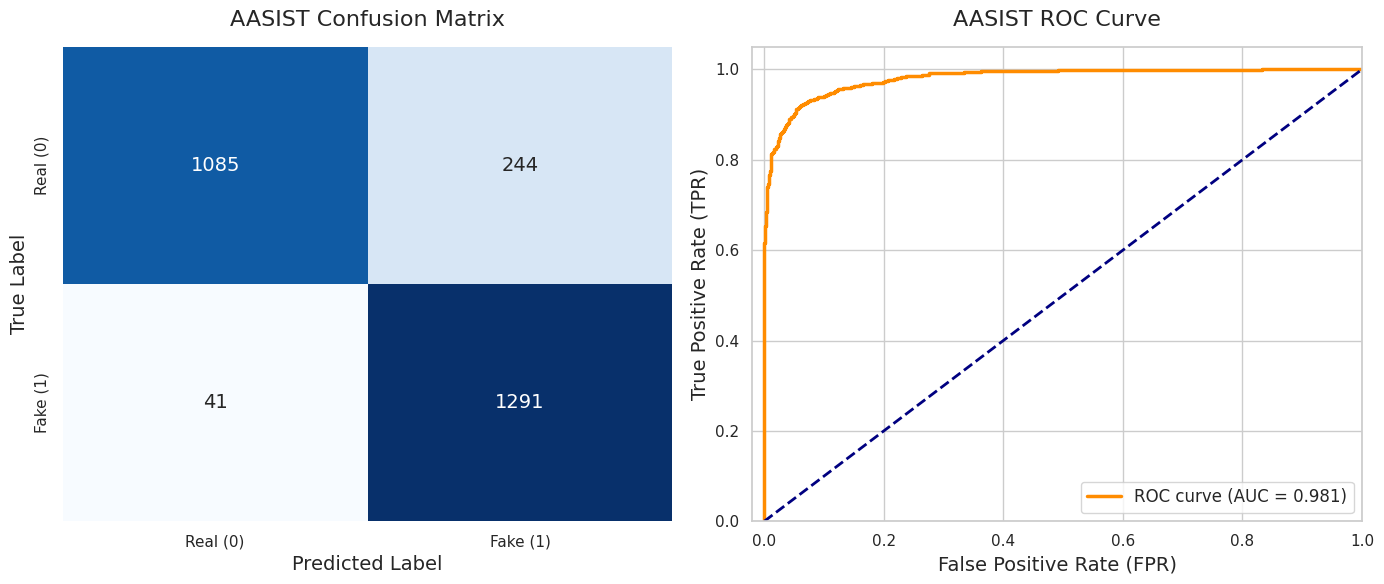

In [ ]:
# ==========================================
# שמירת גרפים לניסוי AASIST
# ==========================================

def save_test_plots_aasist(test_metrics, experiment_dir):
    labels = test_metrics["labels"]
    preds = test_metrics["preds"]
    probs = test_metrics["probs"]

    sns.set_theme(style="whitegrid")

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Confusion Matrix
    cm = confusion_matrix(labels, preds)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[0],
        cbar=False,
        xticklabels=["Real (0)", "Fake (1)"],
        yticklabels=["Real (0)", "Fake (1)"]
    )

    axes[0].set_title("AASIST Confusion Matrix")
    axes[0].set_xlabel("Predicted Label")
    axes[0].set_ylabel("True Label")

    # ROC Curve
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    axes[1].plot([0, 1], [0, 1], linestyle="--")

    axes[1].set_title("AASIST ROC Curve")
    axes[1].set_xlabel("False Positive Rate")
    axes[1].set_ylabel("True Positive Rate")
    axes[1].legend(loc="lower right")

    plt.tight_layout()

    plot_path = os.path.join(
        experiment_dir,
        "test_plots.png"
    )

    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Plots saved to:", plot_path)


save_test_plots_aasist(
    test_metrics,
    EXPERIMENT_DIR
)

In [ ]:
# ==========================================
# דוח מפורט לפי סוג התקפה - AASIST
# ==========================================

def create_attack_type_report_aasist(test_metrics, experiment_dir):
    results_df = pd.DataFrame({
        "path": test_metrics["paths"],
        "attack_type": test_metrics["attack_types"],
        "label": test_metrics["labels"],
        "prediction": test_metrics["preds"],
        "p_fake": test_metrics["probs"]
    })

    results_df["correct"] = results_df["label"] == results_df["prediction"]

    detailed_path = os.path.join(
        experiment_dir,
        "detailed_predictions.csv"
    )

    results_df.to_csv(detailed_path, index=False)

    summary = (
        results_df
        .groupby("attack_type")
        .agg(
            total_files=("label", "count"),
            correct_predictions=("correct", "sum"),
            wrong_predictions=("correct", lambda x: (~x).sum()),
            detected_as_fake=("prediction", lambda x: (x == 1).sum()),
            missed_as_real=("prediction", lambda x: (x == 0).sum()),
            accuracy=("correct", "mean")
        )
        .reset_index()
    )

    summary_path = os.path.join(
        experiment_dir,
        "attack_type_summary.csv"
    )

    summary.to_csv(summary_path, index=False)

    print("Detailed predictions saved to:", detailed_path)
    print("Attack type summary saved to:", summary_path)

    return results_df, summary


detailed_predictions, attack_type_summary = create_attack_type_report_aasist(
    test_metrics,
    EXPERIMENT_DIR
)

display(attack_type_summary)

Generating detailed report by attack type (AASIST)...


  0%|          | 0/666 [00:00<?, ?it/s]

,attack_type,total_files,correct_predictions,wrong_predictions,detected_as_fake,missed_as_real,accuracy
0,elevenlabs_fake,222.0,219.0,3.0,219.0,3.0,0.986486
1,neural_vocoder_autoregressive,222.0,214.0,8.0,214.0,8.0,0.963964
2,neural_vocoder_nonautoregressive,222.0,221.0,1.0,221.0,1.0,0.995495
3,real,1329.0,1085.0,244.0,244.0,1085.0,0.816403
4,traditional_vocoder,222.0,212.0,10.0,212.0,10.0,0.954955
5,unknown,222.0,222.0,0.0,222.0,0.0,1.000000
6,waveform_concatenation,222.0,203.0,19.0,203.0,19.0,0.914414



Detailed results saved to /content/aasist_detailed_results.csv


In [ ]:
# ==========================================
# חיזוי על קובץ אודיו יחיד - AASIST
# ==========================================

def predict_single_file_aasist(
    file_path,
    model,
    device,
    config
):
    model.eval()

    target_sample_rate = config["target_sample_rate"]
    nb_samp = config["nb_samp"]

    try:
        waveform, sample_rate = torchaudio.load(file_path)
    except Exception as e:
        return {
            "error": f"Could not load audio file: {e}"
        }

    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    if sample_rate != target_sample_rate:
        resampler = torchaudio.transforms.Resample(
            orig_freq=sample_rate,
            new_freq=target_sample_rate
        )
        waveform = resampler(waveform)

    waveform = waveform.squeeze(0)

    if waveform.shape[0] > nb_samp:
        start = (waveform.shape[0] - nb_samp) // 2
        waveform = waveform[start:start + nb_samp]
    else:
        pad_length = nb_samp - waveform.shape[0]
        waveform = F.pad(waveform, (0, pad_length))

    input_values = waveform.unsqueeze(0).to(device)

    with torch.no_grad():
        _, logits = model(
            input_values,
            Freq_aug=False
        )

        probs = torch.softmax(logits, dim=-1)[0]

    pred_class = torch.argmax(probs).item()
    pred_label = "FAKE" if pred_class == 1 else "REAL"

    return {
        "file_path": file_path,
        "prediction": pred_label,
        "p_real": float(probs[0].item()),
        "p_fake": float(probs[1].item())
    }

In [ ]:
file_to_test = "/content/ElevenLabs_2026-03-09T13_31_32_Titan - Deep, Bold, and Powerful_pvc_sp100_s34_sb75_se44_b_m2.mp3"

result = predict_single_file_aasist(
    file_path=file_to_test,
    model=model,
    device=device,
    config=CONFIG
)

print("Prediction:", result["prediction"])
print(f"Real Probability: {result['p_real']:.4f}")
print(f"Fake Probability: {result['p_fake']:.4f}")

{'label': 'FAKE', 'p_real': 0.1808941662311554, 'p_fake': 0.819105863571167}
